### Neural Ordinary Differential Equations for Irregular Time Series

The Issue: When we apply models that try to make predictions over time based on sequences of data, we typically imagine the data coming in like the regular clicks of a metronome. But in reality, our data does not tend to come in quite as regularly. Sometimes sensor reading are missing, and we do not get data back for a few days, but then at others, patients go in to see the doctor with extreme regularity.
The more serious issue with these non-continuous sequences of data points relates to the problem that each new data point should take our position along time forwards and yet because each data point cannot be assumed to take the position 1 step forward from the last we often just take to the extreme and say the we know nothing what will happen at a new data point, other than some position at this 1D location of time.

<>:193: SyntaxWarning: invalid escape sequence '\D'
<>:193: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_7530/2640147239.py:193: SyntaxWarning: invalid escape sequence '\D'
  axes[0, 2].set_xlabel('Time Gap Since Last Event ($\Delta t$)')


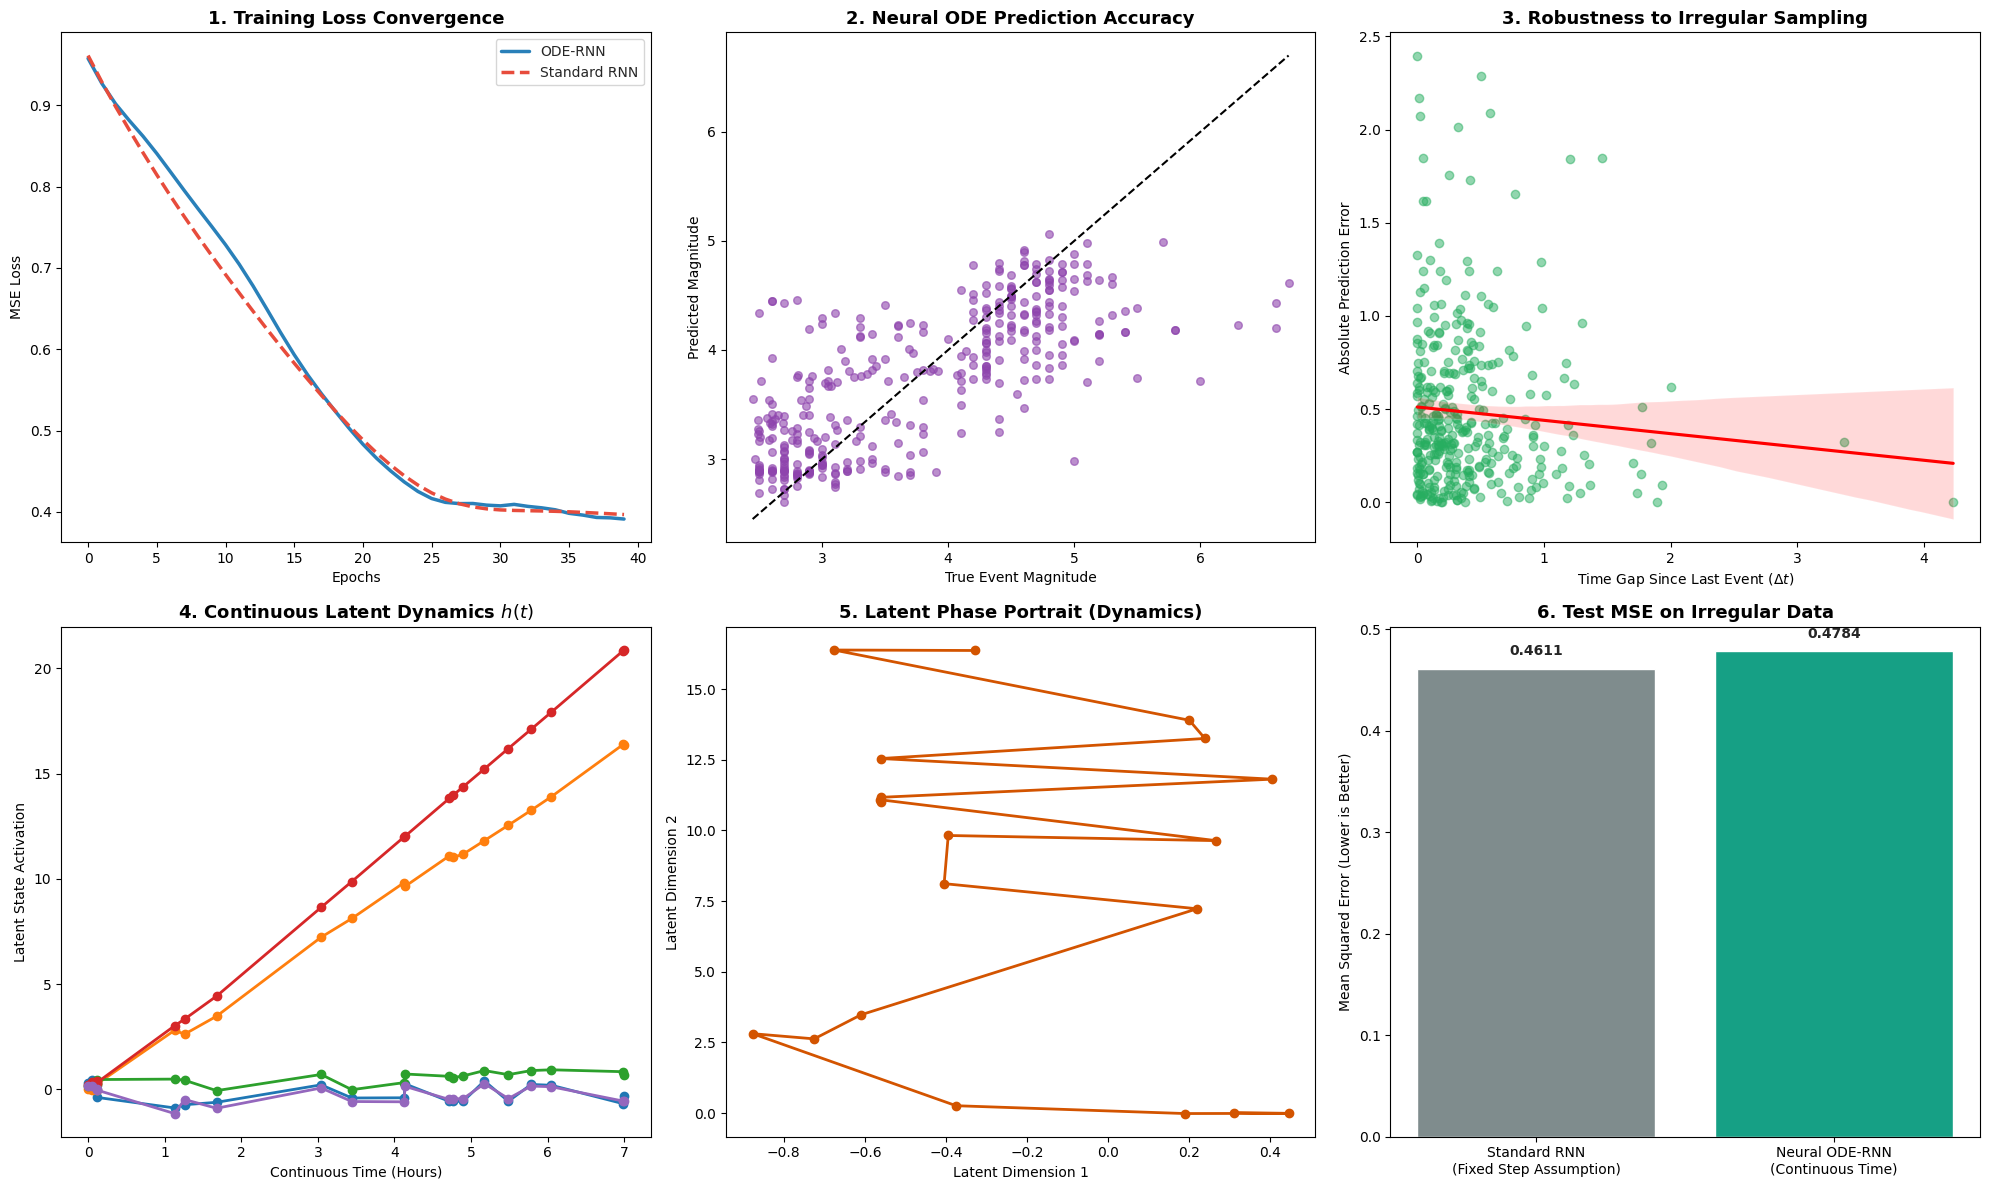

In [1]:

!pip install -q torchdiffeq

import os
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

class ODEFunc(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.Tanh(),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )

    def forward(self, t, h):
        return self.net(h)

class ODERNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.ode_func = ODEFunc(hidden_dim)
        self.gru_cell = nn.GRUCell(input_dim, hidden_dim)
        self.regressor = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, t):
        seq_len, batch_size, _ = x.size()
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        predictions = []
        latents = []

        for i in range(seq_len):
            if i > 0:
                t_span = torch.stack([t[i-1], t[i]])
                h = odeint(self.ode_func, h, t_span, method='rk4')[1]

            h = self.gru_cell(x[i], h)
            pred = self.regressor(h)

            predictions.append(pred)
            latents.append(h)

        return torch.stack(predictions), torch.stack(latents)

class StandardRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim)
        self.regressor = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, t_gaps):
        x_with_t = torch.cat([x, t_gaps.unsqueeze(-1).expand(-1, x.size(1), 1)], dim=-1)
        h, _ = self.rnn(x_with_t)
        return self.regressor(h)

def prepare_real_irregular_data(seq_len=20, batch_size=32):
    url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/2.5_month.csv"
    df = pd.read_csv(url)

    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').reset_index(drop=True)

    start_time = df['time'].iloc[0]
    df['hours_since_start'] = (df['time'] - start_time).dt.total_seconds() / 3600.0

    features = ['latitude', 'longitude', 'depth']
    target = 'mag'

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    x_data = scaler_x.fit_transform(df[features].values)
    y_data = scaler_y.fit_transform(df[[target]].values)
    t_data = df['hours_since_start'].values

    num_sequences = len(df) // seq_len
    x_seqs, y_seqs, t_seqs = [], [], []

    for i in range(num_sequences):
        idx_start = i * seq_len
        idx_end = idx_start + seq_len
        x_seqs.append(x_data[idx_start:idx_end])
        y_seqs.append(y_data[idx_start:idx_end])
        t_seqs.append(t_data[idx_start:idx_end])

    x_tensor = torch.FloatTensor(np.array(x_seqs)).transpose(0, 1)
    y_tensor = torch.FloatTensor(np.array(y_seqs)).transpose(0, 1)
    t_tensor = torch.FloatTensor(np.array(t_seqs)).transpose(0, 1)

    t_tensor = t_tensor - t_tensor[0:1, :]

    split_idx = int(x_tensor.size(1) * 0.8)

    train_x = x_tensor[:, :split_idx, :]
    train_y = y_tensor[:, :split_idx, :]
    train_t = t_tensor[:, :split_idx]

    test_x = x_tensor[:, split_idx:, :]
    test_y = y_tensor[:, split_idx:, :]
    test_t = t_tensor[:, split_idx:]

    return train_x, train_y, train_t, test_x, test_y, test_t, scaler_y

def run_neural_ode_analysis():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    train_x, train_y, train_t, test_x, test_y, test_t, scaler_y = prepare_real_irregular_data()

    train_x, train_y, train_t = train_x.to(device), train_y.to(device), train_t.to(device)
    test_x, test_y, test_t = test_x.to(device), test_y.to(device), test_t.to(device)

    ode_model = ODERNN(input_dim=3, hidden_dim=16, output_dim=1).to(device)
    rnn_model = StandardRNN(input_dim=4, hidden_dim=16, output_dim=1).to(device)

    opt_ode = optim.Adam(ode_model.parameters(), lr=0.005)
    opt_rnn = optim.Adam(rnn_model.parameters(), lr=0.005)
    criterion = nn.MSELoss()

    epochs = 40
    ode_losses, rnn_losses = [], []

    for epoch in range(epochs):
        ode_model.train()
        rnn_model.train()

        opt_ode.zero_grad()
        preds_ode, _ = ode_model(train_x, train_t[:, 0])
        loss_ode = criterion(preds_ode, train_y)
        loss_ode.backward()
        opt_ode.step()

        opt_rnn.zero_grad()
        t_gaps = torch.cat([torch.zeros(1, train_t.size(1)).to(device), train_t[1:] - train_t[:-1]], dim=0)
        preds_rnn = rnn_model(train_x, t_gaps)
        loss_rnn = criterion(preds_rnn, train_y)
        loss_rnn.backward()
        opt_rnn.step()

        ode_losses.append(loss_ode.item())
        rnn_losses.append(loss_rnn.item())

    ode_model.eval()
    rnn_model.eval()

    with torch.no_grad():
        test_preds_ode, test_latents = ode_model(test_x, test_t[:, 0])
        t_gaps_test = torch.cat([torch.zeros(1, test_t.size(1)).to(device), test_t[1:] - test_t[:-1]], dim=0)
        test_preds_rnn = rnn_model(test_x, t_gaps_test)

        ode_mse = criterion(test_preds_ode, test_y).item()
        rnn_mse = criterion(test_preds_rnn, test_y).item()

    true_mag = scaler_y.inverse_transform(test_y.cpu().numpy().reshape(-1, 1)).flatten()
    pred_mag_ode = scaler_y.inverse_transform(test_preds_ode.cpu().numpy().reshape(-1, 1)).flatten()

    t_gaps_flat = t_gaps_test.cpu().numpy().flatten()
    errors_ode = np.abs(true_mag - pred_mag_ode)

    latent_traj = test_latents[:, 0, :].cpu().numpy()
    continuous_t = np.linspace(test_t[0, 0].item(), test_t[-1, 0].item(), 100)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    axes[0, 0].plot(ode_losses, color='#2980b9', label='ODE-RNN', linewidth=2.5)
    axes[0, 0].plot(rnn_losses, color='#e74c3c', label='Standard RNN', linewidth=2.5, linestyle='--')
    axes[0, 0].set_title('1. Training Loss Convergence', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('MSE Loss')
    axes[0, 0].legend()

    axes[0, 1].scatter(true_mag, pred_mag_ode, color='#8e44ad', alpha=0.6, s=30)
    axes[0, 1].plot([min(true_mag), max(true_mag)], [min(true_mag), max(true_mag)], color='black', linestyle='--')
    axes[0, 1].set_title('2. Neural ODE Prediction Accuracy', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('True Event Magnitude')
    axes[0, 1].set_ylabel('Predicted Magnitude')

    sns.regplot(x=t_gaps_flat, y=errors_ode, ax=axes[0, 2], scatter_kws={'alpha':0.5, 'color':'#27ae60'}, line_kws={'color':'red'})
    axes[0, 2].set_title('3. Robustness to Irregular Sampling', fontsize=13, fontweight='bold')
    axes[0, 2].set_xlabel('Time Gap Since Last Event ($\Delta t$)')
    axes[0, 2].set_ylabel('Absolute Prediction Error')

    for i in range(min(5, latent_traj.shape[1])):
        axes[1, 0].plot(test_t[:, 0].cpu().numpy(), latent_traj[:, i], marker='o', linewidth=2)
    axes[1, 0].set_title('4. Continuous Latent Dynamics $h(t)$', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Continuous Time (Hours)')
    axes[1, 0].set_ylabel('Latent State Activation')

    axes[1, 1].plot(latent_traj[:, 0], latent_traj[:, 1], color='#d35400', marker='o', linewidth=2)
    axes[1, 1].set_title('5. Latent Phase Portrait (Dynamics)', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Latent Dimension 1')
    axes[1, 1].set_ylabel('Latent Dimension 2')

    models = ['Standard RNN\n(Fixed Step Assumption)', 'Neural ODE-RNN\n(Continuous Time)']
    mses = [rnn_mse, ode_mse]
    bars = axes[1, 2].bar(models, mses, color=['#7f8c8d', '#16a085'])
    axes[1, 2].set_title('6. Test MSE on Irregular Data', fontsize=13, fontweight='bold')
    axes[1, 2].set_ylabel('Mean Squared Error (Lower is Better)')
    for bar in bars:
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_neural_ode_analysis()